In [1]:
import pandas as pd 
import nltk 
from nltk.corpus import stopwords
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer 
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score , confusion_matrix
import matplotlib.pyplot as plt 
from wordcloud import WordCloud
import seaborn as sns

# Import Dataset

In [2]:
df = pd.read_csv(r'C:\Users\amans\Downloads\flipkart_data.csv')
df.head(5)

,review,rating
0,It was nice produt. I like it's design a lot. ...,5
1,awesome sound....very pretty to see this nd th...,5
2,awesome sound quality. pros 7-8 hrs of battery...,4
3,I think it is such a good product not only as ...,5
4,awesome bass sound quality very good bettary l...,5


# Preprocessing the Data

In [4]:
def preprocess_review_stopwords(df):
    df['review'] = df['review'].fillna('').str.lower()
    
    df['review'] = df['review'].apply(
        lambda x: ' '.join(word for word in x.split() if word not in stop_words)
    )
    
    df['sentiment'] = df['rating'].apply(lambda x: 1 if x >= 4 else 0)
    
    return df

# Visualizing the Data

<function matplotlib.pyplot.show(close=None, block=None)>

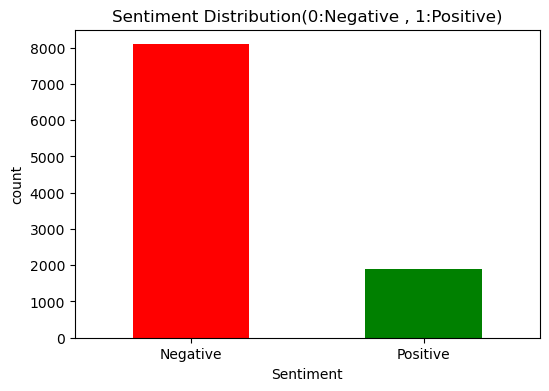

In [7]:
sentiment_count = df_cleaned['sentiment'].value_counts()
plt.figure(figsize=(6,4))
sentiment_count.plot(kind='bar',color=['red','green'])
plt.title('Sentiment Distribution(0:Negative , 1:Positive)')
plt.xlabel('Sentiment')
plt.ylabel('count')
plt.xticks(ticks=[0,1],labels=['Negative','Positive'],rotation=0)
plt.show

# Word Cloud for Positive Reviews

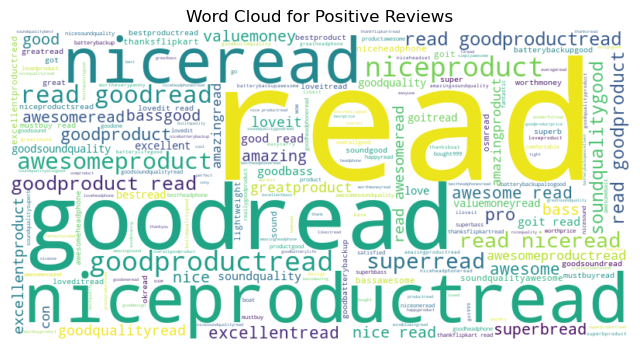

In [11]:
positive_reviews = df_cleaned[df_cleaned['sentiment'] == 1]['review']
positive_text = ' '.join(positive_reviews)
wordcloud = WordCloud(width=800, height=400, background_color='white').generate(positive_text)
plt.figure(figsize=(8,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud for Positive Reviews')
plt.show()

# Vectorizing the Text Data

In [15]:
vectorizer = TfidfVectorizer(max_features=5000)
X = vectorizer.fit_transform(df_cleaned['review'])
y = df_cleaned['sentiment']

# Model Training , Evaluation and Prediction

Accuracy: 0.8356713426853707


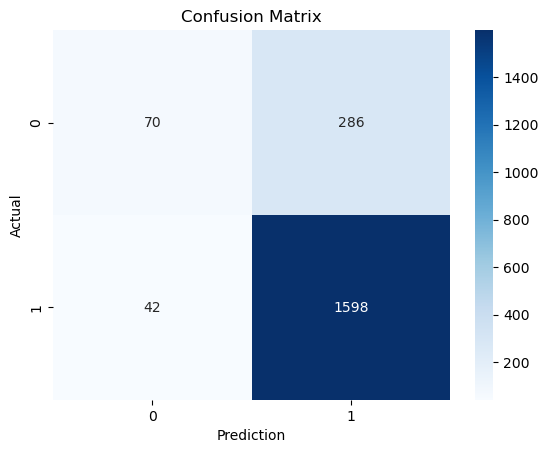

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Create model
model = DecisionTreeClassifier(random_state=42)

# Train model
model.fit(X_train, y_train)

# Predict
y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

# Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)

sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues")
plt.title('Confusion Matrix')
plt.xlabel('Prediction')
plt.ylabel('Actual')
plt.show()